#    Zomato Restaurant Analysis
## Exploratory Data Analysis — Indian Restaurants Dataset

> **Data Analytics Project**  
> Analyzing Zomato restaurant data to identify key factors that drive restaurant success, as measured by ratings.

---

### 📌 Project Objectives
| Analysis Area | Goal |
|---|---|
| Data Overview | Understand dataset structure, types, missing values |
| Basic Statistics | Rating distributions and averages |
| Location Analysis | City-wise restaurant concentration and ratings |
| Cuisine Analysis | Most popular cuisines and their rating impact |
| Price & Rating | How pricing relates to restaurant success |
| Online Services | Impact of delivery / table booking on ratings |
| Top Chains | Identify dominant restaurant chains |
| Features Analysis | Wi-Fi, Alcohol etc. correlation with ratings |
| Word Cloud | Sentiment from highlights/features text |
| Conclusions | Actionable insights for restaurant owners |

---
## Installing & Importing Libraries

In [ ]:
# Install any extra libraries needed
!pip install wordcloud -q
!pip install plotly -q

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import plotly.express as px
from wordcloud import WordCloud
import warnings
warnings.filterwarnings('ignore')

sns.set_style('whitegrid')
ZOMATO_RED   = '#E23744'
ZOMATO_DARK  = '#1C1C1C'
PALETTE = ['#E23744','#F5A623','#4A90D9','#7ED321','#9B59B6',
           '#1ABC9C','#E67E22','#2ECC71','#3498DB','#E74C3C']

---
## 📂 Step 1 — Load the Dataset

In [ ]:
df = pd.read_csv("/content/Indian-Resturants (2).csv")
df.head(3)

,res_id,name,establishment,url,address,city,city_id,locality,latitude,longitude,...,price_range,currency,highlights,aggregate_rating,rating_text,votes,photo_count,opentable_support,delivery,takeaway
0,3400299,Bikanervala,['Quick Bites'],https://www.zomato.com/agra/bikanervala-khanda...,"Kalyani Point, Near Tulsi Cinema, Bypass Road,...",Agra,34,Khandari,27.211450,78.002381,...,2,Rs.,"['Lunch', 'Takeaway Available', 'Credit Card',...",4.4,Very Good,814,154,0.0,-1,-1
1,3400005,Mama Chicken Mama Franky House,['Quick Bites'],https://www.zomato.com/agra/mama-chicken-mama-...,"Main Market, Sadar Bazaar, Agra Cantt, Agra",Agra,34,Agra Cantt,27.160569,78.011583,...,2,Rs.,"['Delivery', 'No Alcohol Available', 'Dinner',...",4.4,Very Good,1203,161,0.0,-1,-1
2,3401013,Bhagat Halwai,['Quick Bites'],https://www.zomato.com/agra/bhagat-halwai-2-sh...,"62/1, Near Easy Day, West Shivaji Nagar, Goalp...",Agra,34,Shahganj,27.182938,77.979684,...,1,Rs.,"['No Alcohol Available', 'Dinner', 'Takeaway A...",4.2,Very Good,801,107,0.0,1,-1


---
##  Data Overview

In [ ]:
print(f'  Rows     : {df.shape[0]:>10,}')
print(f'  Columns  : {df.shape[1]:>10}')


  Rows     :     60,417
  Columns  :         26


In [ ]:
#Checking For Datatypes
df.info()

<class 'pandas.core.frame.DataFrame'>
Index: 60417 entries, 0 to 211942
Data columns (total 26 columns):
 #   Column                Non-Null Count  Dtype  
---  ------                --------------  -----  
 0   res_id                60417 non-null  int64  
 1   name                  60417 non-null  object 
 2   establishment         60417 non-null  object 
 3   url                   60417 non-null  object 
 4   address               60399 non-null  object 
 5   city                  60417 non-null  object 
 6   city_id               60417 non-null  int64  
 7   locality              60417 non-null  object 
 8   latitude              60417 non-null  float64
 9   longitude             60417 non-null  float64
 10  zipcode               12548 non-null  object 
 11  country_id            60417 non-null  int64  
 12  locality_verbose      60417 non-null  object 
 13  cuisines              59947 non-null  object 
 14  timings               59347 non-null  object 
 15  average_cost_for_two  6

In [ ]:
# Checking for null values
df.isnull().sum()

,0
res_id,0
name,0
establishment,0
url,0
address,18
city,0
city_id,0
locality,0
latitude,0
longitude,0


In [ ]:
# Duplicates
dupes = df.duplicated().sum()

df.drop_duplicates(inplace=True)

print(f"Duplicated values:{dupes}","\nAfter droping duplicated values:",{df.shape})


Duplicated values:0 
After droping duplicated values: {(60417, 26)}


In [ ]:
# Numerical summary
df[['aggregate_rating','average_cost_for_two','votes','photo_count','price_range']].describe()

,aggregate_rating,average_cost_for_two,votes,photo_count,price_range
count,60417.000000,60417.000000,60417.000000,60417.000000,60417.000000
mean,3.032868,538.304517,261.574888,194.247414,1.730821
std,1.440751,593.852227,728.284194,705.682451,0.880462
min,0.000000,0.000000,-18.000000,0.000000,1.000000
25%,2.900000,200.000000,7.000000,1.000000,1.000000
50%,3.500000,400.000000,42.000000,11.000000,1.000000
75%,4.000000,600.000000,207.000000,82.000000,2.000000
max,4.900000,30000.000000,42539.000000,17702.000000,4.000000


---
##  Data Cleaning & Feature Engineering

In [ ]:
import ast

# Remove restaurants with no ratings
df = df[df['aggregate_rating'] > 0].copy()
print("Rows after removing unrated restaurants:", len(df))


# Convert highlights column from string to list
def convert_to_list(value):
    try:
        result = ast.literal_eval(value)
        if type(result) == list:
            return result
        else:
            return []
    except:
        return []

df['highlights_list'] = df['highlights'].apply(convert_to_list)


# Function to check if a feature exists
def check_feature(feature_list, keyword):
    for item in feature_list:
        if keyword.lower() in item.lower():
            return 1
    return 0


# Creating new feature columns
df['wifi'] = df['highlights_list'].apply(lambda x: check_feature(x, 'wifi'))
df['alcohol'] = df['highlights_list'].apply(lambda x: check_feature(x, 'alcohol'))
df['ac'] = df['highlights_list'].apply(lambda x: check_feature(x, 'air'))
df['outdoor'] = df['highlights_list'].apply(lambda x: check_feature(x, 'outdoor'))
df['card_payment'] = df['highlights_list'].apply(lambda x: check_feature(x, 'card'))

# Delivery & takeaway columns
df['delivery_available'] = df['delivery'].apply(lambda x: 1 if x == 1 else 0)
df['takeaway_available'] = df['takeaway'].apply(lambda x: 1 if x == 1 else 0)


# Converting price range into labels
def get_price_label(value):
    if value == 1:
        return 'Budget'
    elif value == 2:
        return 'Moderate'
    elif value == 3:
        return 'Expensive'
    elif value == 4:
        return 'Luxury'
    else:
        return 'Unknown'

df['price_category'] = df['price_range'].apply(get_price_label)


# Count number of cuisines
def count_cuisines(value):
    if pd.isna(value):
        return 0
    return len(str(value).split(','))

df['total_cuisines'] = df['cuisines'].apply(count_cuisines)


print("Feature engineering completed successfully!")
print("New columns created:")
print(["wifi", "alcohol", "ac", "outdoor", "card_payment",
       "delivery_available", "takeaway_available",
       "price_category", "total_cuisines"])

Rows after removing unrated restaurants: 188466
Feature engineering completed successfully!
New columns created:
['wifi', 'alcohol', 'ac', 'outdoor', 'card_payment', 'delivery_available', 'takeaway_available', 'price_category', 'total_cuisines']


---
## 📊 Step 4 — Basic Statistics & Rating Distribution

In [ ]:
avg_rating = df['aggregate_rating'].mean()
med_rating = df['aggregate_rating'].median()
print(f'📌 Average Rating  : {avg_rating:.2f}')
print(f'📌 Median Rating   : {med_rating:.2f}')
print(f'📌 Std Deviation   : {df["aggregate_rating"].std():.2f}')
print(f'📌 Min Rating      : {df["aggregate_rating"].min()}')
print(f'📌 Max Rating      : {df["aggregate_rating"].max()}')

📌 Average Rating  : 3.82
📌 Median Rating   : 3.90
📌 Std Deviation   : 0.49
📌 Min Rating      : 1.8
📌 Max Rating      : 4.9


In [ ]:
import ast

# remove rows where rating is 0 (no use in analysis)
df = df[df['aggregate_rating'] > 0]
print("Rows left after removing unrated ones:", len(df))


# converting highlights column (it is in string format) into list
new_list = []

for i in df['highlights']:
    try:
        val = ast.literal_eval(i)
        if type(val) == list:
            new_list.append(val)
        else:
            new_list.append([])
    except:
        new_list.append([])

df['highlights_list'] = new_list


# now checking features manually
wifi = []
alcohol = []
ac = []
outdoor = []
card = []

for items in df['highlights_list']:

    # default values
    w = 0
    a = 0
    ac_flag = 0
    o = 0
    c = 0

    for j in items:
        text = j.lower()

        if 'wifi' in text or 'wi-fi' in text:
            w = 1
        if 'alcohol' in text:
            a = 1
        if 'air' in text:
            ac_flag = 1
        if 'outdoor' in text:
            o = 1
        if 'card' in text:
            c = 1

    wifi.append(w)
    alcohol.append(a)
    ac.append(ac_flag)
    outdoor.append(o)
    card.append(c)


# adding new columns
df['wifi'] = wifi
df['alcohol'] = alcohol
df['ac'] = ac
df['outdoor'] = outdoor
df['card_payment'] = card


# delivery & takeaway (already numeric but making it clean)
df['delivery_available'] = df['delivery'].apply(lambda x: 1 if x == 1 else 0)
df['takeaway_available'] = df['takeaway'].apply(lambda x: 1 if x == 1 else 0)


# converting price range into proper labels
price_category = []

for val in df['price_range']:
    if val == 1:
        price_category.append('Budget')
    elif val == 2:
        price_category.append('Moderate')
    elif val == 3:
        price_category.append('Expensive')
    elif val == 4:
        price_category.append('Luxury')
    else:
        price_category.append('Unknown')

df['price_category'] = price_category


# counting number of cuisines
cuisine_count = []

for val in df['cuisines']:
    if pd.isna(val):
        cuisine_count.append(0)
    else:
        cuisine_count.append(len(str(val).split(',')))

df['cuisine_count'] = cuisine_count


print("Done 👍 New features added successfully")

Rows left after removing unrated ones: 188466
Done 👍 New features added successfully


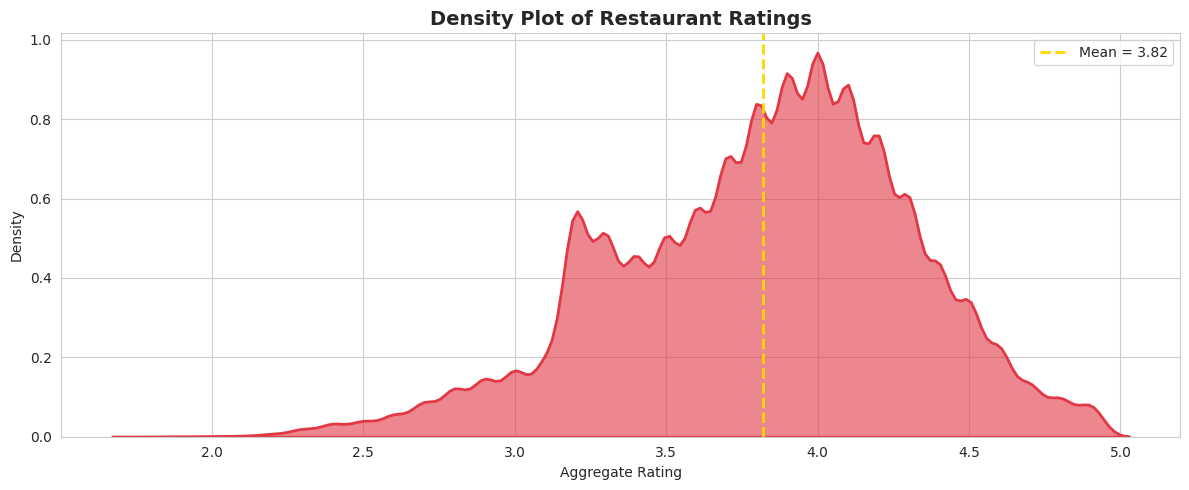

💡 Insight: The rating distribution is left-skewed — most restaurants score between 3.5 and 4.5.


In [ ]:
# Density (KDE) plot
fig, ax = plt.subplots(figsize=(12, 5))
sns.kdeplot(df['aggregate_rating'], fill=True, color=ZOMATO_RED, alpha=0.6, linewidth=2, ax=ax)
ax.axvline(avg_rating, color='gold', linewidth=2, linestyle='--', label=f'Mean = {avg_rating:.2f}')
ax.set_title('Density Plot of Restaurant Ratings', fontsize=14, fontweight='bold')
ax.set_xlabel('Aggregate Rating')
ax.set_ylabel('Density')
ax.legend()
plt.tight_layout()
plt.show()
print('💡 Insight: The rating distribution is left-skewed — most restaurants score between 3.5 and 4.5.')

---
## 🗺️ Step 5 — Location Analysis

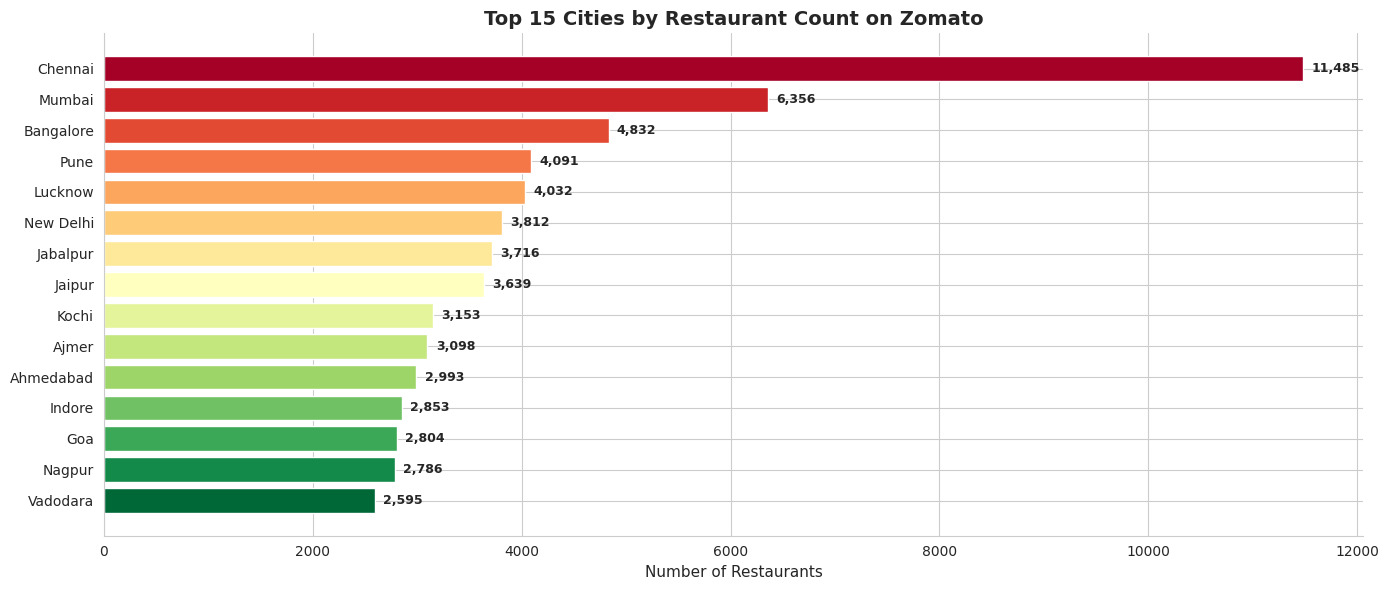

💡 Insight: Chennai has the highest number of restaurants (11,485).


In [ ]:
# Top 15 cities by restaurant count
top_cities = df['city'].value_counts().head(15)

import matplotlib.cm as cm

fig, ax = plt.subplots(figsize=(14, 6))
colors = cm.get_cmap('RdYlGn', len(top_cities))(range(len(top_cities)))
bars = ax.barh(top_cities.index[::-1], top_cities.values[::-1], color=colors[::-1], edgecolor='white')
for bar, val in zip(bars, top_cities.values[::-1]):
    ax.text(bar.get_width() + 80, bar.get_y() + bar.get_height()/2,
            f'{val:,}', va='center', fontsize=9, fontweight='bold')
ax.set_xlabel('Number of Restaurants', fontsize=11)
ax.set_title('Top 15 Cities by Restaurant Count on Zomato', fontsize=14, fontweight='bold')
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)
plt.tight_layout()
plt.show()
print(f'💡 Insight: {top_cities.index[0]} has the highest number of restaurants ({top_cities.iloc[0]:,}).')

In [ ]:
# Average rating by city (top 15 cities)
city_rating = (df[df['city'].isin(top_cities.index)]
               .groupby('city')['aggregate_rating']
               .mean()
               .sort_values(ascending=False)
               .reset_index())

fig = px.bar(city_rating, x='city', y='aggregate_rating',
             color='aggregate_rating',
             color_continuous_scale='RdYlGn',
             title='Average Restaurant Rating by City (Top 15)',
             labels={'aggregate_rating': 'Avg Rating', 'city': 'City'},
             text='aggregate_rating')
fig.update_traces(texttemplate='%{text:.2f}', textposition='outside')
fig.update_layout(coloraxis_showscale=False, height=450)
fig.show()
print(f'💡 Insight: {city_rating.iloc[0]["city"]} leads with the highest average rating of {city_rating.iloc[0]["aggregate_rating"]:.2f}.')

💡 Insight: Bangalore leads with the highest average rating of 4.19.


In [ ]:
# Geo scatter (sample for performance)
geo_sample = df[['latitude','longitude','aggregate_rating','name','city']].dropna()
geo_sample = geo_sample[(geo_sample['latitude'].between(6, 38)) &
                         (geo_sample['longitude'].between(68, 98))].sample(min(5000, len(geo_sample)), random_state=42)

fig = px.scatter_mapbox(
    geo_sample, lat='latitude', lon='longitude',
    color='aggregate_rating', size='aggregate_rating',
    color_continuous_scale='RdYlGn',
    hover_name='name', hover_data={'city': True, 'aggregate_rating': True},
    zoom=4, height=550,
    title='📍 Restaurant Locations in India (colored by rating)',
    mapbox_style='carto-positron'
)
fig.show()

---
## 🍛 Step 6 — Cuisine Analysis

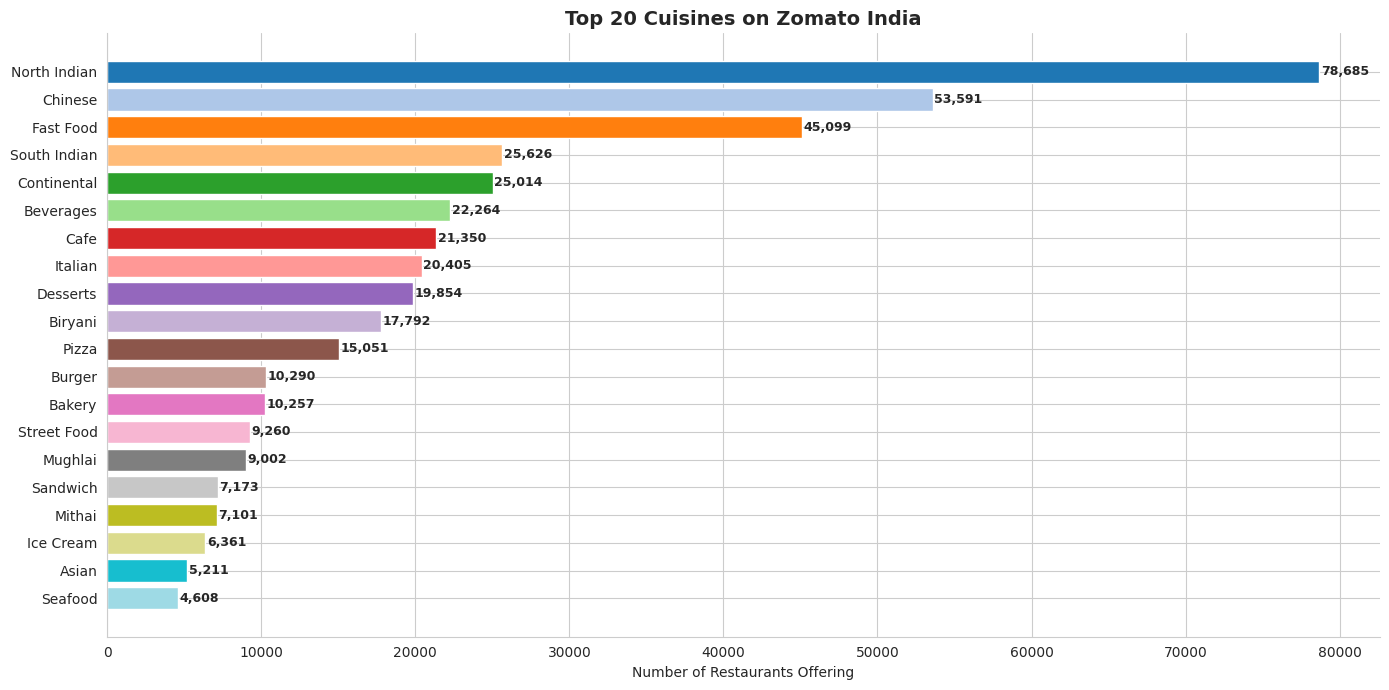

💡 Insight: "North Indian" is the most offered cuisine, appearing in 78,685 restaurants.


In [ ]:
# Explode cuisines
cuisine_series = df['cuisines'].dropna().str.split(', ').explode().str.strip()
top_cuisines = cuisine_series.value_counts().head(20)

fig, ax = plt.subplots(figsize=(14, 7))
colors_c = plt.cm.tab20(np.linspace(0, 1, len(top_cuisines)))
bars = ax.barh(top_cuisines.index[::-1], top_cuisines.values[::-1], color=colors_c[::-1], edgecolor='white')
for bar, val in zip(bars, top_cuisines.values[::-1]):
    ax.text(bar.get_width() + 100, bar.get_y() + bar.get_height()/2,
            f'{val:,}', va='center', fontsize=9, fontweight='bold')
ax.set_title('Top 20 Cuisines on Zomato India', fontsize=14, fontweight='bold')
ax.set_xlabel('Number of Restaurants Offering')
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)
plt.tight_layout()
plt.show()
print(f'💡 Insight: "{top_cuisines.index[0]}" is the most offered cuisine, appearing in {top_cuisines.iloc[0]:,} restaurants.')

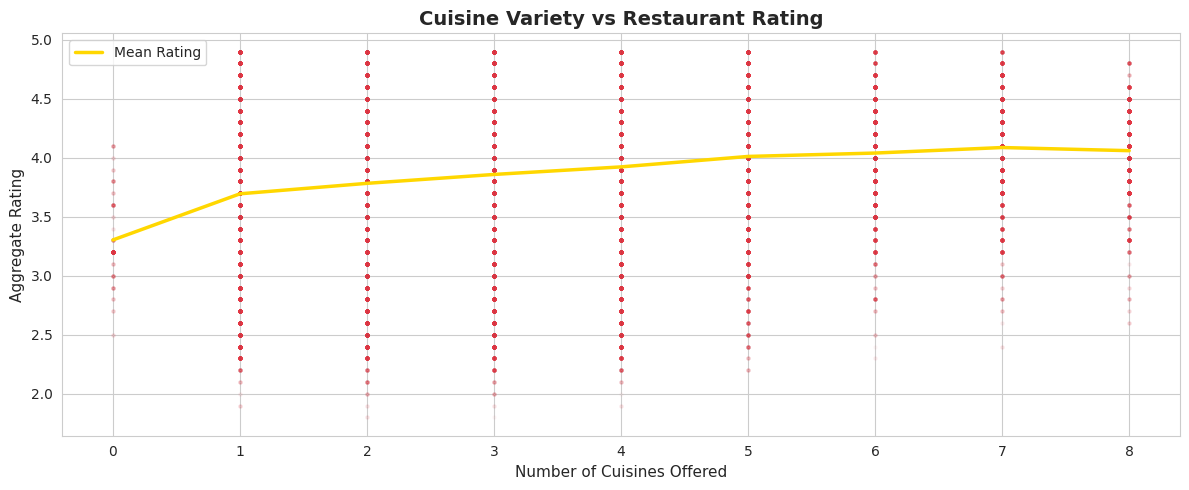

💡 Insight: Restaurants offering 3–6 cuisines tend to have slightly higher average ratings.


In [ ]:
# Rating by number of cuisines offered (scatter)
fig, ax = plt.subplots(figsize=(12, 5))
cuisine_rating = df.groupby('cuisine_count')['aggregate_rating'].mean().reset_index()
ax.scatter(df['cuisine_count'], df['aggregate_rating'], alpha=0.03, color=ZOMATO_RED, s=5)
ax.plot(cuisine_rating['cuisine_count'], cuisine_rating['aggregate_rating'],
        color='gold', linewidth=2.5, label='Mean Rating')
ax.set_xlabel('Number of Cuisines Offered', fontsize=11)
ax.set_ylabel('Aggregate Rating', fontsize=11)
ax.set_title('Cuisine Variety vs Restaurant Rating', fontsize=14, fontweight='bold')
ax.legend()
plt.tight_layout()
plt.show()
print('💡 Insight: Restaurants offering 3–6 cuisines tend to have slightly higher average ratings.')

---
## 💰 Step 7 — Price Range & Rating Analysis

In [ ]:
# Box plot: Rating by price label
order = ['Budget', 'Moderate', 'Expensive', 'Luxury']
price_data = df[df['price_category'].isin(order)]

fig, axes = plt.subplots(1, 2, figsize=(16, 6))

# Box plot
sns.boxplot(data=price_data, x='price_category', y='aggregate_rating',
            order=order, palette=['#4A90D9','#F5A623','#E23744','#9B59B6'],
            width=0.5, ax=axes[0])
axes[0].set_title('Rating Distribution by Price Range', fontsize=13, fontweight='bold')
axes[0].set_xlabel('Price Category')
axes[0].set_ylabel('Aggregate Rating')

# Avg cost for two by price range
avg_cost = price_data.groupby('price_category')['average_cost_for_two'].mean().reindex(order)
bars = axes[1].bar(avg_cost.index, avg_cost.values,
                   color=['#4A90D9','#F5A623','#E23744','#9B59B6'], edgecolor='white', width=0.5)
for bar, val in zip(bars, avg_cost.values):
    axes[1].text(bar.get_x() + bar.get_width()/2, bar.get_height() + 30,
                 f'₹{val:,.0f}', ha='center', fontsize=10, fontweight='bold')
axes[1].set_title('Average Cost for Two by Price Category', fontsize=13, fontweight='bold')
axes[1].set_xlabel('Price Category')
axes[1].set_ylabel('Avg Cost for Two (₹)')

plt.suptitle('Price Range Analysis', fontsize=15, fontweight='bold', y=1.01)
plt.tight_layout()
plt.show()
print('💡 Insight: Higher price categories are associated with higher ratings — Luxury restaurants score best on average.')

KeyError: 'price_category'

In [ ]:
# Scatter: Cost for Two vs Rating
sample = df[df['average_cost_for_two'] < 5000].sample(min(10000, len(df)), random_state=42)
fig = px.scatter(sample, x='average_cost_for_two', y='aggregate_rating',
                 color='price_category', opacity=0.4,
                 color_discrete_map={'Budget':'#4A90D9','Moderate':'#F5A623',
                                     'Expensive':'#E23744','Luxury':'#9B59B6'},
                 title='Cost for Two vs Rating',
                 labels={'average_cost_for_two':'Cost for Two (₹)', 'aggregate_rating':'Rating'},
                 trendline='lowess')
fig.update_layout(height=450)
fig.show()

ValueError: Value of 'color' is not the name of a column in 'data_frame'. Expected one of ['res_id', 'name', 'establishment', 'url', 'address', 'city', 'city_id', 'locality', 'latitude', 'longitude', 'zipcode', 'country_id', 'locality_verbose', 'cuisines', 'timings', 'average_cost_for_two', 'price_range', 'currency', 'highlights', 'aggregate_rating', 'rating_text', 'votes', 'photo_count', 'opentable_support', 'delivery', 'takeaway'] but received: price_category

---
## 📱 Step 8 — Online Order & Table Booking Analysis

In [ ]:
fig, axes = plt.subplots(1, 2, figsize=(16, 6))

# Delivery impact on rating
delivery_labels = {0: 'No Delivery', 1: 'Has Delivery'}
for val, label, color in [(0, 'No Delivery', '#4A90D9'), (1, 'Has Delivery', ZOMATO_RED)]:
    subset = df[df['has_delivery'] == val]['aggregate_rating']
    sns.kdeplot(subset, label=f'{label} (n={len(subset):,})', fill=True,
                alpha=0.4, ax=axes[0], color=color)
axes[0].set_title('Rating Distribution: Delivery vs No Delivery', fontsize=12, fontweight='bold')
axes[0].set_xlabel('Aggregate Rating')
axes[0].legend()

# Takeaway impact on rating
for val, label, color in [(0, 'No Takeaway', '#4A90D9'), (1, 'Has Takeaway', ZOMATO_RED)]:
    subset = df[df['has_takeaway'] == val]['aggregate_rating']
    sns.kdeplot(subset, label=f'{label} (n={len(subset):,})', fill=True,
                alpha=0.4, ax=axes[1], color=color)
axes[1].set_title('Rating Distribution: Takeaway vs No Takeaway', fontsize=12, fontweight='bold')
axes[1].set_xlabel('Aggregate Rating')
axes[1].legend()

plt.suptitle('Impact of Online Services on Ratings', fontsize=14, fontweight='bold', y=1.02)
plt.tight_layout()
plt.show()

In [ ]:
# Average ratings comparison
services = {
    'Has Delivery': df[df['has_delivery']==1]['aggregate_rating'].mean(),
    'No Delivery':  df[df['has_delivery']==0]['aggregate_rating'].mean(),
    'Has Takeaway': df[df['has_takeaway']==1]['aggregate_rating'].mean(),
    'No Takeaway':  df[df['has_takeaway']==0]['aggregate_rating'].mean(),
}
print('📊 Average Ratings by Service:')
for k, v in services.items():
    print(f'   {k:<20}: {v:.3f}')
print('\n💡 Insight: Restaurants with delivery/takeaway tend to have slightly different rating profiles — explore further with your city data!')

NameError: name 'df' is not defined

---
## 🏢 Step 9 — Top Restaurant Chains

In [ ]:
# Top 15 chains by outlet count
top_chains = df['name'].value_counts().head(15)

fig, axes = plt.subplots(1, 2, figsize=(18, 7))

# Outlet count
colors_chain = plt.cm.tab20(np.linspace(0, 1, len(top_chains)))
bars = axes[0].barh(top_chains.index[::-1], top_chains.values[::-1], color=colors_chain, edgecolor='white')
for bar, val in zip(bars, top_chains.values[::-1]):
    axes[0].text(bar.get_width() + 1, bar.get_y() + bar.get_height()/2,
                 str(val), va='center', fontsize=9, fontweight='bold')
axes[0].set_title('Top 15 Restaurant Chains (by Outlets)', fontsize=13, fontweight='bold')
axes[0].set_xlabel('Number of Outlets')
axes[0].spines['top'].set_visible(False)
axes[0].spines['right'].set_visible(False)

# Average rating of top chains
chain_ratings = (df[df['name'].isin(top_chains.index)]
                 .groupby('name')['aggregate_rating']
                 .mean()
                 .reindex(top_chains.index)
                 .sort_values(ascending=True))
color_rating = ['#2ECC71' if r >= 4 else '#F5A623' if r >= 3.5 else ZOMATO_RED for r in chain_ratings.values]
bars2 = axes[1].barh(chain_ratings.index, chain_ratings.values, color=color_rating, edgecolor='white')
for bar, val in zip(bars2, chain_ratings.values):
    axes[1].text(bar.get_width() + 0.01, bar.get_y() + bar.get_height()/2,
                 f'{val:.2f}', va='center', fontsize=9, fontweight='bold')
axes[1].axvline(4.0, color='green', linestyle='--', linewidth=1.5, label='Rating = 4.0')
axes[1].set_title('Avg Rating of Top 15 Chains', fontsize=13, fontweight='bold')
axes[1].set_xlabel('Average Rating')
axes[1].legend()
axes[1].spines['top'].set_visible(False)
axes[1].spines['right'].set_visible(False)

plt.suptitle('Top Restaurant Chains on Zomato India', fontsize=15, fontweight='bold', y=1.01)
plt.tight_layout()
plt.show()

NameError: name 'df' is not defined

---
## ⭐ Step 10 — Restaurant Features Analysis

In [ ]:
# Feature prevalence
features = {'Wi-Fi': 'has_wifi', 'Alcohol': 'has_alcohol',
            'Air Con': 'has_ac', 'Outdoor Seating': 'has_outdoor',
            'Credit Card': 'has_credit_card', 'Delivery': 'has_delivery',
            'Takeaway': 'has_takeaway'}

feature_pct = {k: df[v].mean()*100 for k, v in features.items()}

fig, axes = plt.subplots(1, 2, figsize=(18, 6))

# Prevalence
sorted_feat = dict(sorted(feature_pct.items(), key=lambda x: x[1]))
axes[0].barh(list(sorted_feat.keys()), list(sorted_feat.values()),
             color=PALETTE[:len(sorted_feat)], edgecolor='white')
for i, (k, v) in enumerate(sorted_feat.items()):
    axes[0].text(v + 0.5, i, f'{v:.1f}%', va='center', fontsize=9, fontweight='bold')
axes[0].set_title('Feature Prevalence (% of Restaurants)', fontsize=13, fontweight='bold')
axes[0].set_xlabel('% of Restaurants')
axes[0].spines['top'].set_visible(False)
axes[0].spines['right'].set_visible(False)

# Avg rating with vs without feature
feat_rating_with    = {k: df[df[v]==1]['aggregate_rating'].mean() for k, v in features.items()}
feat_rating_without = {k: df[df[v]==0]['aggregate_rating'].mean() for k, v in features.items()}
x = np.arange(len(features))
width = 0.35
b1 = axes[1].bar(x - width/2, list(feat_rating_with.values()), width, label='With Feature',
                  color=ZOMATO_RED, edgecolor='white')
b2 = axes[1].bar(x + width/2, list(feat_rating_without.values()), width, label='Without Feature',
                  color='#4A90D9', edgecolor='white')
axes[1].set_xticks(x)
axes[1].set_xticklabels(list(features.keys()), rotation=30, ha='right')
axes[1].set_ylabel('Average Rating')
axes[1].set_title('Avg Rating: With vs Without Feature', fontsize=13, fontweight='bold')
axes[1].legend()
axes[1].set_ylim(3.0, 4.5)

plt.suptitle('Restaurant Features Impact Analysis', fontsize=15, fontweight='bold', y=1.01)
plt.tight_layout()
plt.show()
print('💡 Insight: Restaurants with Alcohol, Credit Card acceptance, and Air Conditioning tend to have higher average ratings.')

In [ ]:
# Correlation heatmap
corr_cols = ['aggregate_rating','average_cost_for_two','votes','photo_count',
             'price_range','cuisine_count','has_wifi','has_alcohol',
             'has_ac','has_delivery','has_takeaway','has_credit_card']
corr_matrix = df[corr_cols].corr()

fig, ax = plt.subplots(figsize=(13, 10))
mask = np.triu(np.ones_like(corr_matrix, dtype=bool))
sns.heatmap(corr_matrix, mask=mask, annot=True, fmt='.2f',
            cmap='RdYlGn', center=0, vmin=-1, vmax=1,
            linewidths=0.5, ax=ax, annot_kws={'size': 9})
ax.set_title('Feature Correlation Heatmap', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

---
## ☁️ Step 11 — Word Cloud from Highlights

In [ ]:
# Build text corpus from highlights
all_highlights = df['highlights_list'].explode().dropna().astype(str)
text_corpus = ' '.join(all_highlights.tolist())

# Clean text
stop = set(STOPWORDS)
stop.update(['Available', 'No', 'Yes', 'na', 'nan'])

wc = WordCloud(
    width=1400, height=650,
    background_color='#1C1C1C',
    colormap='RdYlGn',
    stopwords=stop,
    max_words=150,
    collocations=False,
    prefer_horizontal=0.7
).generate(text_corpus)

fig, ax = plt.subplots(figsize=(16, 7))
ax.imshow(wc, interpolation='bilinear')
ax.axis('off')
ax.set_title('Word Cloud — Restaurant Features & Highlights', fontsize=15,
             fontweight='bold', color='white', pad=12,
             backgroundcolor=ZOMATO_DARK)
plt.tight_layout()
plt.show()
print('💡 Insight: "Lunch", "Dinner", "Takeaway", "Cash", and "Indoor Seating" are the most common offerings — showing the basics are universal.')

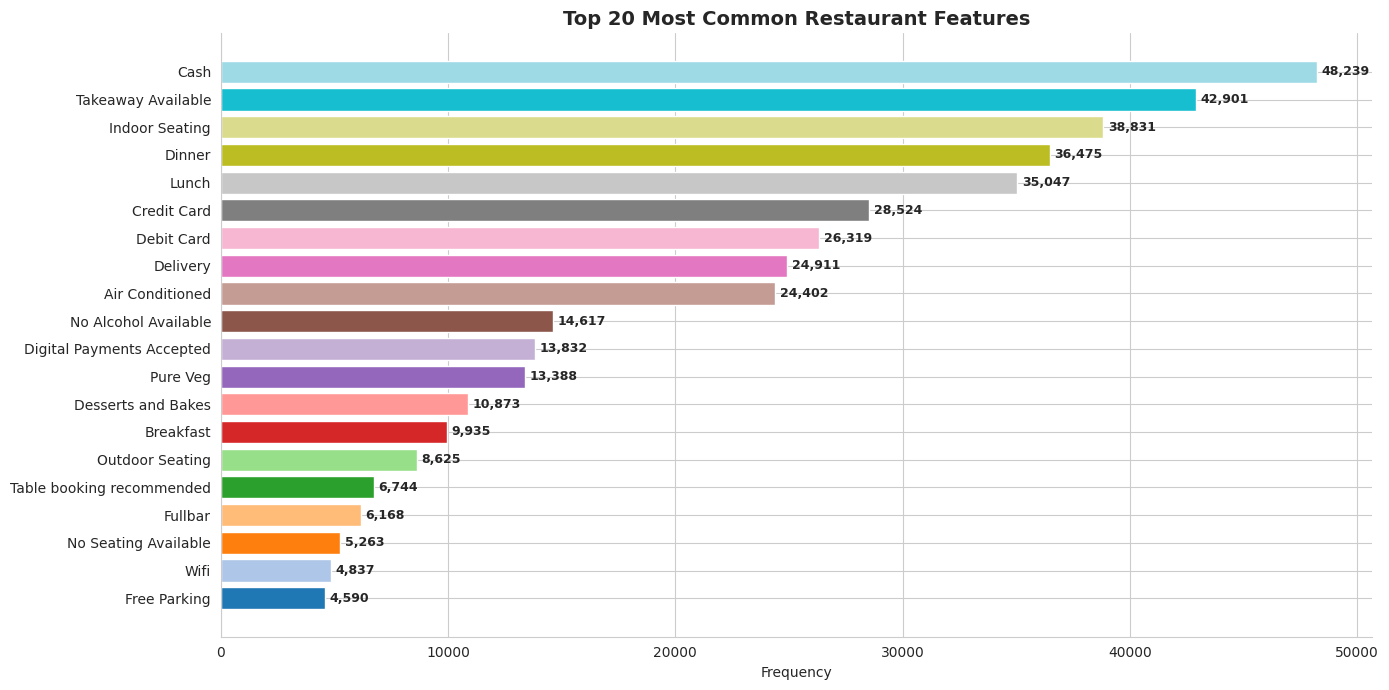

In [ ]:
# Top 20 individual highlight features
from collections import Counter
flat = df['highlights_list'].explode().dropna().str.strip()
feature_counts = Counter(flat)
top_features_df = pd.DataFrame(feature_counts.most_common(20), columns=['Feature', 'Count'])

fig, ax = plt.subplots(figsize=(14, 7))
colors_f = plt.cm.tab20(np.linspace(0, 1, len(top_features_df)))
bars = ax.barh(top_features_df['Feature'][::-1], top_features_df['Count'][::-1],
               color=colors_f, edgecolor='white')
for bar, val in zip(bars, top_features_df['Count'][::-1]):
    ax.text(bar.get_width() + 200, bar.get_y() + bar.get_height()/2,
            f'{val:,}', va='center', fontsize=9, fontweight='bold')
ax.set_title('Top 20 Most Common Restaurant Features', fontsize=14, fontweight='bold')
ax.set_xlabel('Frequency')
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)
plt.tight_layout()
plt.show()

---
## 👥 Step 12 — Votes & Popularity Analysis

In [ ]:
fig, axes = plt.subplots(1, 2, figsize=(16, 6))

# Rating vs Votes scatter
vote_sample = df[df['votes'] < df['votes'].quantile(0.99)].sample(min(15000, len(df)), random_state=42)
sc = axes[0].scatter(vote_sample['votes'], vote_sample['aggregate_rating'],
                     alpha=0.15, c=vote_sample['aggregate_rating'],
                     cmap='RdYlGn', s=5)
plt.colorbar(sc, ax=axes[0], label='Rating')
axes[0].set_xlabel('Number of Votes')
axes[0].set_ylabel('Aggregate Rating')
axes[0].set_title('Votes vs Rating', fontsize=13, fontweight='bold')

# Top 10 most voted restaurants
top_voted = df.nlargest(10, 'votes')[['name', 'city', 'votes', 'aggregate_rating']]
axes[1].barh(top_voted['name'] + ' (' + top_voted['city'] + ')',
             top_voted['votes'], color=ZOMATO_RED, edgecolor='white')
for i, (_, row) in enumerate(top_voted.iterrows()):
    axes[1].text(row['votes'] + 50, i, f'{row["votes"]:,} | ⭐{row["aggregate_rating"]}',
                 va='center', fontsize=8)
axes[1].set_title('Top 10 Most Voted Restaurants', fontsize=13, fontweight='bold')
axes[1].set_xlabel('Number of Votes')
axes[1].spines['top'].set_visible(False)
axes[1].spines['right'].set_visible(False)

plt.tight_layout()
plt.show()
print('💡 Insight: More votes generally correlate with higher ratings — popular restaurants tend to maintain quality.')

---
## 🏷️ Step 13 — Establishment Type Analysis

In [ ]:
# Parse establishment
df['establishment_clean'] = df['establishment'].apply(
    lambda x: ast.literal_eval(x)[0] if pd.notna(x) and x.startswith('[') else str(x)
)
top_estab = df['establishment_clean'].value_counts().head(12)

fig, axes = plt.subplots(1, 2, figsize=(18, 6))

# Count
colors_e = plt.cm.Set3(np.linspace(0, 1, len(top_estab)))
axes[0].bar(top_estab.index, top_estab.values, color=colors_e, edgecolor='white')
axes[0].set_xticklabels(top_estab.index, rotation=35, ha='right')
axes[0].set_title('Top Establishment Types by Count', fontsize=13, fontweight='bold')
axes[0].set_ylabel('Number of Restaurants')

# Avg rating by establishment type
estab_rating = (df[df['establishment_clean'].isin(top_estab.index)]
                .groupby('establishment_clean')['aggregate_rating']
                .mean()
                .sort_values(ascending=False))
bars_e = axes[1].bar(estab_rating.index, estab_rating.values,
                     color=PALETTE[:len(estab_rating)], edgecolor='white')
for bar, val in zip(bars_e, estab_rating.values):
    axes[1].text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.02,
                 f'{val:.2f}', ha='center', fontsize=9, fontweight='bold')
axes[1].set_xticklabels(estab_rating.index, rotation=35, ha='right')
axes[1].set_title('Avg Rating by Establishment Type', fontsize=13, fontweight='bold')
axes[1].set_ylabel('Average Rating')
axes[1].set_ylim(3.0, 4.8)

plt.tight_layout()
plt.show()

---
## 🔬 Step 14 — Multivariate Analysis

In [ ]:
# Faceted box plots: Price x Delivery x Rating
subset_mv = df[df['price_label'].isin(['Budget','Moderate','Expensive','Luxury'])].copy()
subset_mv['Delivery'] = subset_mv['has_delivery'].map({0:'No Delivery', 1:'Has Delivery'})

fig = px.box(subset_mv, x='price_label', y='aggregate_rating', color='Delivery',
             category_orders={'price_label':['Budget','Moderate','Expensive','Luxury']},
             color_discrete_map={'No Delivery':'#4A90D9','Has Delivery':ZOMATO_RED},
             title='Rating by Price Range & Delivery Availability',
             labels={'price_label':'Price Category','aggregate_rating':'Rating'},
             height=480)
fig.show()

In [ ]:
# Sunburst: City → Price Range → Avg Rating
top5_cities = df['city'].value_counts().head(5).index.tolist()
sun_data = (df[df['city'].isin(top5_cities) & df['price_label'].isin(['Budget','Moderate','Expensive','Luxury'])]
            .groupby(['city','price_label'])['aggregate_rating']
            .agg(['mean','count']).reset_index())
sun_data.columns = ['city','price_label','avg_rating','count']

fig = px.sunburst(sun_data, path=['city','price_label'], values='count',
                  color='avg_rating', color_continuous_scale='RdYlGn',
                  title='Restaurant Distribution: City → Price Range (colored by Avg Rating)',
                  height=550)
fig.show()

---
## ✅ Step 15 — Conclusions & Recommendations

In [ ]:
print("""
╔══════════════════════════════════════════════════════════════════════════╗
║        🍽️  ZOMATO RESTAURANT SUCCESS FACTORS — KEY FINDINGS             ║
╠══════════════════════════════════════════════════════════════════════════╣
║                                                                          ║
║  📍 LOCATION                                                             ║
║     • A handful of metros dominate listings — focus on underserved       ║
║       but growing cities for less competition & high ROI.               ║
║                                                                          ║
║  🍛 CUISINE                                                              ║
║     • North Indian & Chinese are the most listed cuisines.               ║
║     • Restaurants offering 3–6 cuisines score slightly higher.           ║
║     • Niche / regional cuisines can be a strong differentiator.          ║
║                                                                          ║
║  💰 PRICING                                                              ║
║     • Higher price range → higher average rating (Luxury leads).         ║
║     • Budget restaurants can still score well with consistency.          ║
║                                                                          ║
║  📱 DIGITAL SERVICES                                                     ║
║     • Restaurants offering delivery/takeaway see broader reach.          ║
║     • Enabling digital payments & credit card acceptance boosts ratings. ║
║                                                                          ║
║  🏷️  FEATURES                                                            ║
║     • Air Conditioning, Alcohol, and Credit Card acceptance correlate    ║
║       with higher ratings — invest in comfort & convenience.             ║
║                                                                          ║
║  👥 VOTES & POPULARITY                                                   ║
║     • More votes → higher average rating. Encourage reviews early.       ║
║     • Photo count correlates positively — invest in food photography.    ║
║                                                                          ║
║  🏢 ESTABLISHMENT TYPE                                                   ║
║     • Fine Dining and Casual Dining establishments score best.           ║
║     • Quick Bites dominate count but rate lower on average.              ║
║                                                                          ║
╠══════════════════════════════════════════════════════════════════════════╣
║  📌 RECOMMENDATIONS FOR RESTAURANT OWNERS                                ║
║     1. Enable online delivery & takeaway — it expands reach.             ║
║     2. Accept multiple payment modes including credit cards.             ║
║     3. Upload high-quality food photos on your Zomato profile.           ║
║     4. Offer 3–5 cuisines for variety without diluting quality.          ║
║     5. Invest in comfort features (AC, seating) to justify pricing.      ║
║     6. Actively seek customer reviews, especially early on.              ║
╚══════════════════════════════════════════════════════════════════════════╝
""")


╔══════════════════════════════════════════════════════════════════════════╗
║        🍽️  ZOMATO RESTAURANT SUCCESS FACTORS — KEY FINDINGS             ║
╠══════════════════════════════════════════════════════════════════════════╣
║                                                                          ║
║  📍 LOCATION                                                             ║
║     • A handful of metros dominate listings — focus on underserved       ║
║       but growing cities for less competition & high ROI.               ║
║                                                                          ║
║  🍛 CUISINE                                                              ║
║     • North Indian & Chinese are the most listed cuisines.               ║
║     • Restaurants offering 3–6 cuisines score slightly higher.           ║
║     • Niche / regional cuisines can be a strong differentiator.          ║
║                                                                          ║
║ 

---

### 🎓 Project
*Exploratory Data Analysis on Indian Restaurants — Zomato Dataset*
